In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd

from metpy.plots import SkewT, Hodograph
import metpy.calc as mpcalc
from metpy.units import units

In [6]:
from datetime import datetime
from siphon.simplewebservice.wyoming import WyomingUpperAir

date = datetime(2023, 7, 7, 0)
station = 'JAX'
df = WyomingUpperAir.request_data(date, station)

In [7]:
h = df['height'].values
p = df['pressure'].values
T = df['temperature'].values
Td = df['dewpoint'].values
u = df['u_wind'].values
v = df['v_wind'].values

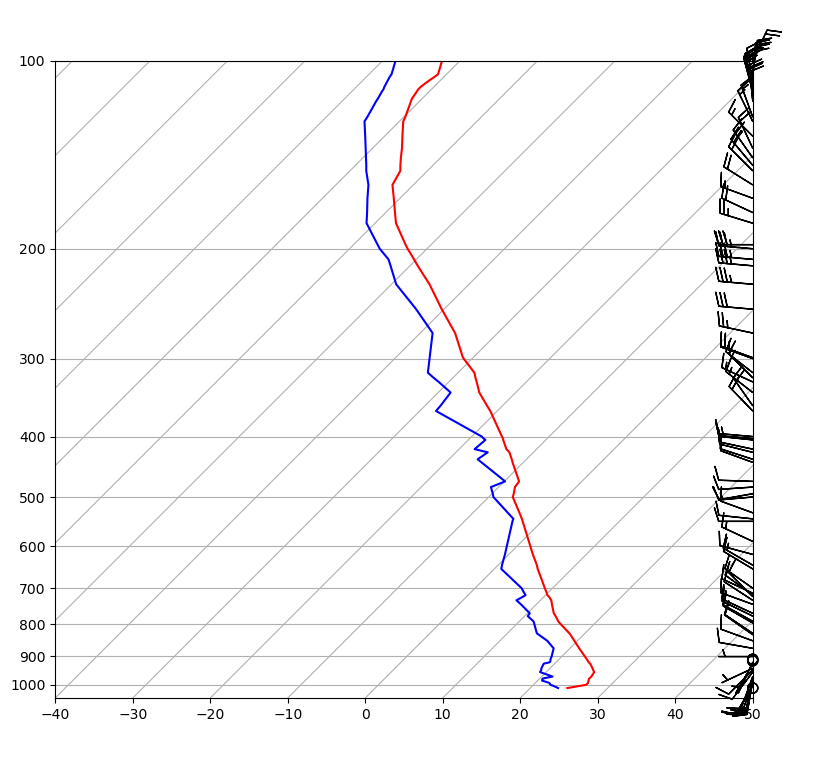

In [8]:
# make figure and `SkewT` object
fig = plt.figure(figsize=(9, 9))
skewt = SkewT(fig=fig, rotation=45)

# plot sounding data
skewt.plot(p, T, 'r')  # air temperature
skewt.plot(p, Td, 'b')  # dew point
skewt.plot_barbs(p[p >= 100], u[p >= 100], v[p >= 100])  # wind barbs

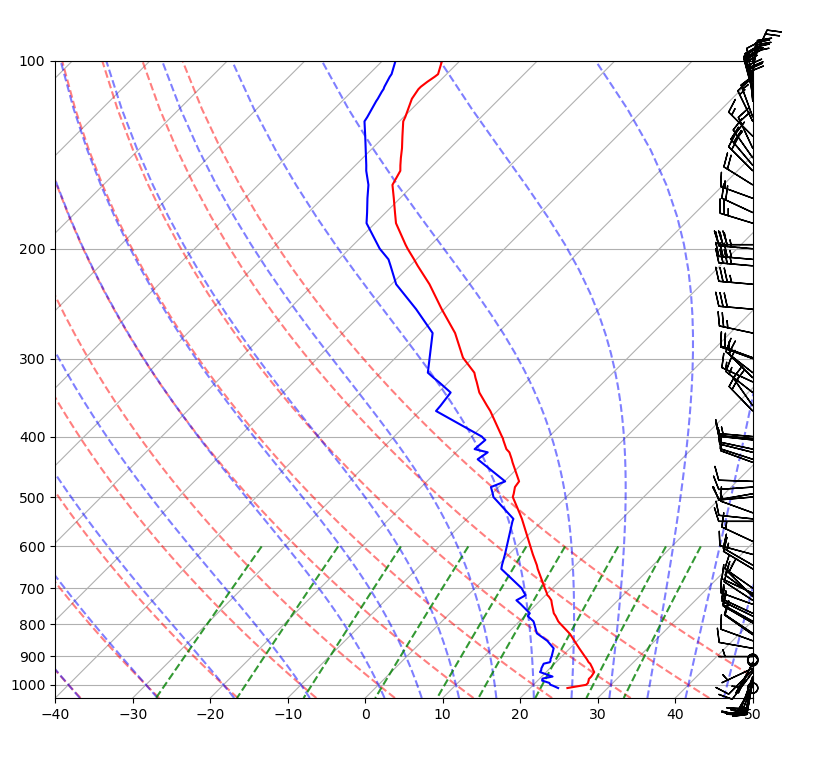

In [9]:
# make figure and `SkewT` object
fig2 = plt.figure(figsize=(9, 9))
skewt2 = SkewT(fig=fig2, rotation=45)

# plot sounding data
skewt2.plot(p, T, 'r') # air temperature
skewt2.plot(p, Td, 'b') # dew point
skewt2.plot_barbs(p[p >= 100], u[p >= 100], v[p >= 100])  # wind barbs

# add dry adiabats, moist adiabats, and mixing ratio lines
skewt2.plot_dry_adiabats()
skewt2.plot_moist_adiabats()
skewt2.plot_mixing_lines()